<a href="https://colab.research.google.com/github/sadumina/Deep-Learning-Assignment-Group-ID-5/blob/Finalize-Models/densenet-Apitos2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetic Retinopathy Classification — DenseNet121 (Transfer Learning)

**Dataset:** APTOS 2019 Blindness Detection, pre-processed version *Diabetic Retinopathy 224x224 Gaussian Filtered* (Kaggle, 3,662 fundus images).
**Task:** 5-class severity grading — No DR, Mild, Moderate, Severe, Proliferative DR.
**Approach:** DenseNet121 pre-trained on ImageNet, trained in two stages:
1. **Feature extraction** — backbone frozen, only a new classification head is trained.
2. **Fine-tuning** — the last 60 backbone layers are unfrozen and trained with a very small learning rate.

**Fair comparison:** the train/validation split is identical to the Classic-CNN model (80/20, `seed=42`).

## 1. Environment setup
Mount Google Drive (to save results permanently) and import the libraries.

In [1]:
# Mount Google Drive so checkpoints and plots survive a Colab disconnect
from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# Confirm a GPU is available
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration
All key settings in one place. `SEED`, `IMG_SIZE` and the 20% validation split must stay the same as the Classic-CNN notebook so both models see the same images.

In [2]:
SEED = 42
IMG_SIZE = (224, 224)     # DenseNet121's native input size
BATCH_SIZE = 32
VAL_SPLIT = 0.2           # 80% train / 20% validation

STAGE1_EPOCHS = 10        # head training (frozen backbone)
STAGE2_EPOCHS = 20        # fine-tuning
STAGE1_LR = 1e-3
STAGE2_LR = 1e-5          # small LR so pretrained weights are not destroyed
UNFREEZE_LAST = 60        # number of DenseNet121 layers to unfreeze in stage 2

# All outputs (models, plots) are saved here on Google Drive
OUT_DIR = "/content/drive/MyDrive/DL Assignment/Data/DR_DenseNet121_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)   # reproducible weights, shuffling and augmentation

## 3. Load the dataset
The dataset is stored in Google Drive as a zip file (`My Drive/DL Assignment/Data.zip`).
It is unzipped to Colab's local disk, which is much faster than reading thousands of small files from Drive.

In [3]:
# ---- Load data from Google Drive (zip file) ----
# My Drive > DL Assignment > Data.zip
ZIP_PATH = "/content/drive/MyDrive/DL Assignment/Data.zip"

# Unzip to Colab's local disk
DATA_ROOT = "/content/data"
if os.path.isdir(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)          # remove any previous incomplete copy
print("Unzipping dataset...")
shutil.unpack_archive(ZIP_PATH, DATA_ROOT)
print("Done.")

# Find the folder that directly contains the 5 class folders (works however the zip is nested)
DATA_DIR = next(d for d, sub, _ in os.walk(DATA_ROOT) if "No_DR" in sub and "Mild" in sub)
print("DATA_DIR:", DATA_DIR)

# Check image counts per class (must total 3662)
total = 0
for cls in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, cls)
    if os.path.isdir(p):
        n = len(os.listdir(p)); total += n
        print(f"{cls:15s} {n}")
print("Total:", total)
assert total == 3662, "Dataset incomplete"

Unzipping dataset...
Done.
DATA_DIR: /content/data/gaussian_filtered_images/gaussian_filtered_images
Mild            370
Moderate        999
No_DR           1805
Proliferate_DR  295
Severe          193
Total: 3662


## 4. Train / validation split

Expected output: **2930 files for training, 732 files for validation.**

In [4]:
common = dict(validation_split=VAL_SPLIT, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

raw_train = tf.keras.utils.image_dataset_from_directory(DATA_DIR, subset="training", **common)
raw_val   = tf.keras.utils.image_dataset_from_directory(DATA_DIR, subset="validation", **common)

print("Folder order (Keras labels):", raw_train.class_names)

Found 3662 files belonging to 5 classes.
Using 2930 files for training.
Found 3662 files belonging to 5 classes.
Using 732 files for validation.
Folder order (Keras labels): ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


## 5. Label remapping and preprocessing
**Label order:** Keras numbers classes alphabetically (Mild=0, Moderate=1, No_DR=2, ...). APTOS uses clinical severity order (0 = No DR → 4 = Proliferative DR). We remap to the clinical order so that *quadratic weighted kappa* — the official APTOS metric — is meaningful.

**Preprocessing:** DenseNet121's ImageNet weights expect `densenet.preprocess_input` (scale to 0–1, then normalise with ImageNet mean/std), not plain `/255`.

In [5]:
CLASS_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]   # clinical order 0..4
LABEL_OF = {name: i for i, name in enumerate(CLASS_ORDER)}

# Lookup table: alphabetical Keras label -> clinical label
REMAP = tf.constant([LABEL_OF[name] for name in raw_train.class_names])
preprocess = tf.keras.applications.densenet.preprocess_input

def fix(images, labels):
    return preprocess(images), tf.gather(REMAP, labels)

AUTOTUNE = tf.data.AUTOTUNE
# cache() keeps decoded images in memory after the first epoch -> faster training
train_ds = raw_train.map(fix, num_parallel_calls=AUTOTUNE).cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
# cache() on validation also fixes its order, so predictions and labels always line up
val_ds   = raw_val.map(fix, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

## 6. Class weights
The dataset is heavily imbalanced (No_DR ≈ 1805 images vs Severe ≈ 193). Class weights make mistakes on rare classes cost more, so the model doesn't just predict No_DR.

The weights are **softened** with a square root: full "balanced" weights made the model over-predict the rare classes and pushed Moderate accuracy down to 22%. Moderate, Severe and Proliferate_DR then get small extra multipliers (×1.2, ×1.4, ×1.3) to make the per-class accuracy more even.

Class weights change how much each image counts in the loss, not the number of images, so the counts table below stays imbalanced.

In [6]:
# Read labels from the file paths (no need to load the images)
train_labels = np.array([LABEL_OF[os.path.basename(os.path.dirname(p))] for p in raw_train.file_paths])
val_labels   = np.array([LABEL_OF[os.path.basename(os.path.dirname(p))] for p in raw_val.file_paths])

# Number of images per class (this stays imbalanced - weights change importance, not counts)
print(pd.DataFrame({"train": np.bincount(train_labels, minlength=5),
                    "val":   np.bincount(val_labels, minlength=5)}, index=CLASS_ORDER))

# Class weights: softened, with extra weight for the harder classes
weights = compute_class_weight("balanced", classes=np.arange(5), y=train_labels)
weights = np.sqrt(weights)     # soften: rare classes still get help, but not too much
weights[2] *= 1.2              # Moderate: small extra boost
weights[3] *= 1.4              # Severe: extra weight (fewest training images)
weights[4] *= 1.3              # Proliferate_DR: extra weight
CLASS_WEIGHT = dict(enumerate(weights))
print("\nClass weights:", {CLASS_ORDER[k]: round(v, 2) for k, v in CLASS_WEIGHT.items()})

                train  val
No_DR            1442  363
Mild              311   59
Moderate          794  205
Severe            147   46
Proliferate_DR    236   59

Class weights: {'No_DR': np.float64(0.64), 'Mild': np.float64(1.37), 'Moderate': np.float64(1.03), 'Severe': np.float64(2.8), 'Proliferate_DR': np.float64(2.05)}


## 7. Model architecture
- **Data augmentation** (training only): random flips, small rotations and zoom — fundus images have no fixed orientation.
- **Backbone:** DenseNet121 with ImageNet weights, without its original 1000-class head.
- **New head:** Global Average Pooling → Dropout(0.3) → Dense(5, softmax).

`training=False` keeps the backbone's BatchNorm layers in inference mode, which keeps fine tuning stable.

In [7]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),    # up to ±36 degrees
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

base = tf.keras.applications.DenseNet121(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base.trainable = False    # frozen for stage 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = augment(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="densenet121_dr")
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_dr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,042,629 (26.87 MB)

 Trainable params: 5,125 (20.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 8. Callbacks
- **EarlyStopping** — stops when validation loss stops improving and restores the best weights.
- **ReduceLROnPlateau** — lowers the learning rate when progress stalls.
- **ModelCheckpoint** — saves the best model to Google Drive.

In [8]:
def get_callbacks(stage):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
        tf.keras.callbacks.ModelCheckpoint(f"{OUT_DIR}/densenet121_{stage}_best.keras",
                                           monitor="val_loss", save_best_only=True),
    ]

## 9. Stage 1 — Train the classification head
Only the new Dense layer learns; the DenseNet121 backbone is used as a fixed feature extractor.

In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(STAGE1_LR),
              loss="sparse_categorical_crossentropy",   # labels are integers 0..4
              metrics=["accuracy"])

hist1 = model.fit(train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS,
                  class_weight=CLASS_WEIGHT, callbacks=get_callbacks("stage1"))

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 343ms/step - accuracy: 0.5379 - loss: 1.5371 - val_accuracy: 0.7090 - val_loss: 0.8994 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - accuracy: 0.6304 - loss: 1.2791 - val_accuracy: 0.7240 - val_loss: 0.8080 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.6703 - loss: 1.1593 - val_accuracy: 0.7145 - val_loss: 0.8224 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - accuracy: 0.6874 - loss: 1.1265 - val_accuracy: 0.7391 - val_loss: 0.7510 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.6874 - loss: 1.0916 - val_accuracy: 0.7336 - val_loss: 0.7787 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.7075 - loss: 1.0670 - val_accuracy: 0.7199 - val_loss: 0.7750 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.7150 - loss: 1.

## 10. Stage 2 — Fine-tune the top of DenseNet121
Unfreeze the last `UNFREEZE_LAST` layers so the high-level features adapt to retinal images. The learning rate is 100× smaller than stage 1 so the pre-trained weights are adjusted gently, not overwritten.

In [10]:
base.trainable = True
for layer in base.layers[:-UNFREEZE_LAST]:
    layer.trainable = False     # keep early layers (edges, textures) frozen

print("Trainable layers in backbone:", sum(l.trainable for l in base.layers))

# Re-compile is required after changing trainable flags
model.compile(optimizer=tf.keras.optimizers.Adam(STAGE2_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

hist2 = model.fit(train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS,
                  class_weight=CLASS_WEIGHT, callbacks=get_callbacks("stage2"))

Trainable layers in backbone: 60
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 284ms/step - accuracy: 0.6495 - loss: 1.2352 - val_accuracy: 0.7227 - val_loss: 0.7858 - learning_rate: 1.0000e-05
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step - accuracy: 0.6638 - loss: 1.1505 - val_accuracy: 0.7227 - val_loss: 0.7913 - learning_rate: 1.0000e-05
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.6788 - loss: 1.1421 - val_accuracy: 0.7213 - val_loss: 0.7843 - learning_rate: 1.0000e-05
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.6884 - loss: 1.0940 - val_accuracy: 0.7227 - val_loss: 0.7644 - learning_rate: 1.0000e-05
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.6898 - loss: 1.0743 - val_accuracy: 0.7227 - val_loss: 0.7536 - learning_rate: 1.0000e-05
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.6990 - loss: 1.0656 - val_accuracy: 0.7227 - val_loss: 0.7470 - learning_rate: 1.0000e-05
Epoch 7/20
92/92 ━━━━━━━━

## 11. Training curves
Accuracy and loss across both stages. The dashed line marks where fine tuning begins.

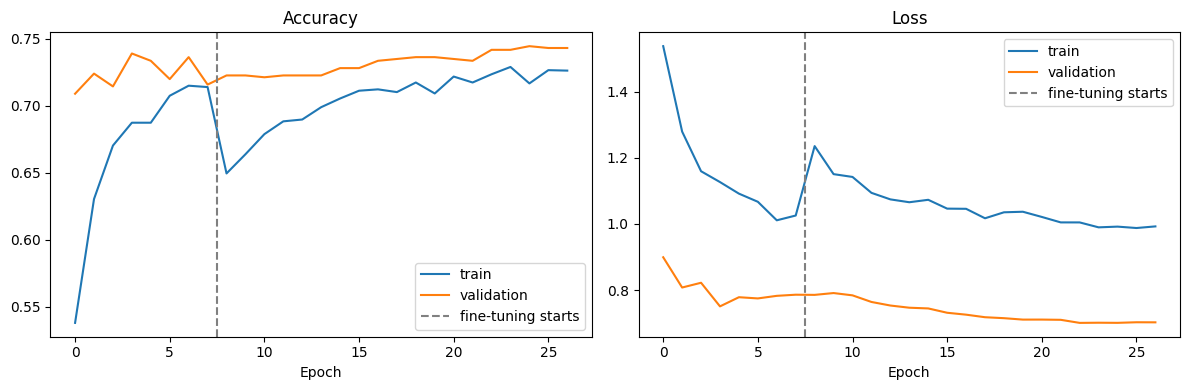

In [11]:
h = {k: hist1.history[k] + hist2.history[k] for k in ["accuracy", "val_accuracy", "loss", "val_loss"]}
split_epoch = len(hist1.history["loss"]) - 0.5

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, metric in zip(ax, ["accuracy", "loss"]):
    a.plot(h[metric], label="train")
    a.plot(h["val_" + metric], label="validation")
    a.axvline(split_epoch, ls="--", c="gray", label="fine-tuning starts")
    a.set_title(metric.capitalize()); a.set_xlabel("Epoch"); a.legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/densenet121_curves.png", dpi=150)
plt.show()

## 12. Evaluation
Metrics on the validation set:

- **Classification report** — precision, recall and F1-score per class.
- **Quadratic Weighted Kappa (QWK)** — official APTOS metric; penalises predictions more the further they are from the true grade.
- **Confusion matrix** — which grades get confused with each other.
- **Per-class accuracy** — the share of each grade predicted correctly (same as recall).
- **Overall vs average accuracy** — overall accuracy counts every image equally; average per-class accuracy counts every class equally, showing the effect of class imbalance.

Labels and predictions are collected in the same loop so their order always matches.

In [12]:
y_true, y_pred = [], []
for images, labels in val_ds:
    y_true.append(labels.numpy())
    y_pred.append(model.predict_on_batch(images).argmax(axis=1))
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=CLASS_ORDER, digits=3))
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print(f"Quadratic Weighted Kappa: {qwk:.4f}")

                precision    recall  f1-score   support

         No_DR      0.936     0.961     0.948       363
          Mild      0.438     0.593     0.504        59
      Moderate      0.678     0.576     0.623       205
        Severe      0.375     0.391     0.383        46
Proliferate_DR      0.404     0.390     0.397        59

      accuracy                          0.742       732
     macro avg      0.566     0.582     0.571       732
  weighted avg      0.745     0.742     0.741       732

Quadratic Weighted Kappa: 0.8079


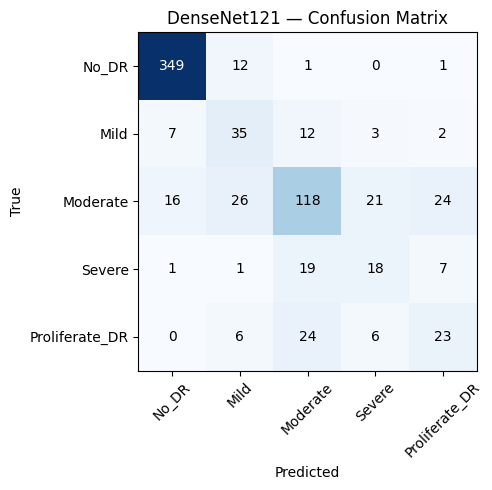

Per-class accuracy:
No_DR           96%
Mild            59%
Moderate        58%
Severe          39%
Proliferate_DR  39%

Overall accuracy:          74.2%
Average per-class accuracy: 58.2%


In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(5), CLASS_ORDER, rotation=45)
plt.yticks(range(5), CLASS_ORDER)
for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("DenseNet121 — Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/densenet121_confusion.png", dpi=150)
plt.show()

# Accuracy (recall) for each class
recall = cm.diagonal() / cm.sum(axis=1)
print("Per-class accuracy:")
for name, r in zip(CLASS_ORDER, recall):
    print(f"{name:15s} {r:.0%}")

# Average accuracy
overall_acc  = cm.diagonal().sum() / cm.sum()    # all images counted equally
balanced_acc = recall.mean()                      # each class counted equally
print(f"\nOverall accuracy:          {overall_acc:.1%}")
print(f"Average per-class accuracy: {balanced_acc:.1%}")

## 13. Save the final model

In [16]:
model.save(f"{OUT_DIR}/densenet121_final.keras")
print("Saved model, checkpoints and plots to:", OUT_DIR)

Saved model, checkpoints and plots to: /content/drive/MyDrive/DL Assignment/Data/DR_DenseNet121_outputs
